# 📊 Stock Market Trend & Volatility Analysis with Prediction

This project analyzes stock trends, volatility, and predicts future prices using machine learning techniques.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## 📥 Data Collection & Loading

The dataset was obtained from Yahoo Finance and contains historical stock prices for RELIANCE, TCS, and NIFTY.

In [4]:
#Load Dataset
stock = pd.read_csv("stock_data.csv", header=[0,1], index_col=0)
stock.head()

Price            Close                                   High               \
Ticker     RELIANCE.NS       TCS.NS         ^NSEI RELIANCE.NS       TCS.NS   
Date                                                                         
2020-01-01  675.324219  1866.114014  12182.500000  683.152914  1880.146719   
2020-01-02  686.821228  1857.547729  12282.200195  689.348791  1876.746120   
2020-01-03  687.648804  1894.567261  12226.650391  689.661895  1913.808742   
2020-01-06  671.700684  1894.394775  11993.049805  683.510767  1916.348043   
2020-01-07  682.034607  1899.043579  12052.950195  686.463396  1906.619440   

Price                            Low                                   Open  \
Ticker             ^NSEI RELIANCE.NS       TCS.NS         ^NSEI RELIANCE.NS   
Date                                                                          
2020-01-01  12222.200195  673.490123  1854.405520  12165.299805  679.081997   
2020-01-02  12289.900391  676.397899  1850.273061  12195.250000  676.397899   
2020-01-03  12265.599609  681.318729  1863.014897  12191.349609  685.792252   
2020-01-06  12179.099609  670.134933  1883.590282  11974.200195  679.976719   
2020-01-07  12152.150391  677.068950  1880.060420  12005.349609  679.529381   

Price                                      Volume                     
Ticker           TCS.NS         ^NSEI RELIANCE.NS   TCS.NS     ^NSEI  
Date                                                                  
2020-01-01  1866.458295  12202.150391    14004468  1354908  304100.0  
2020-01-02  1876.746120  12198.549805    17710316  2380752  407700.0  
2020-01-03  1863.014897  12261.099609    20984698  4655761  428800.0  
2020-01-06  1898.311969  12170.599609    24519177  3023209  396500.0  
2020-01-07  1894.437614  12079.099609    16683622  2429317  447800.0

## 🧹 Data Cleaning

The dataset was checked for missing values and duplicate records to ensure data quality before analysis.

In [5]:
#Clean Column Name
stock.columns = ['_'.join(col).strip() for col in stock.columns]
stock.head()

,Close_RELIANCE.NS,Close_TCS.NS,Close_^NSEI,High_RELIANCE.NS,High_TCS.NS,High_^NSEI,Low_RELIANCE.NS,Low_TCS.NS,Low_^NSEI,Open_RELIANCE.NS,Open_TCS.NS,Open_^NSEI,Volume_RELIANCE.NS,Volume_TCS.NS,Volume_^NSEI
Date,,,,,,,,,,,,,,,
2020-01-01,675.324219,1866.114014,12182.500000,683.152914,1880.146719,12222.200195,673.490123,1854.405520,12165.299805,679.081997,1866.458295,12202.150391,14004468,1354908,304100.0
2020-01-02,686.821228,1857.547729,12282.200195,689.348791,1876.746120,12289.900391,676.397899,1850.273061,12195.250000,676.397899,1876.746120,12198.549805,17710316,2380752,407700.0
2020-01-03,687.648804,1894.567261,12226.650391,689.661895,1913.808742,12265.599609,681.318729,1863.014897,12191.349609,685.792252,1863.014897,12261.099609,20984698,4655761,428800.0
2020-01-06,671.700684,1894.394775,11993.049805,683.510767,1916.348043,12179.099609,670.134933,1883.590282,11974.200195,679.976719,1898.311969,12170.599609,24519177,3023209,396500.0
2020-01-07,682.034607,1899.043579,12052.950195,686.463396,1906.619440,12152.150391,677.068950,1880.060420,12005.349609,679.529381,1894.437614,12079.099609,16683622,2429317,447800.0


In [6]:
#Change Index to Date
stock.index = pd.to_datetime(stock.index)
stock.head()

,Close_RELIANCE.NS,Close_TCS.NS,Close_^NSEI,High_RELIANCE.NS,High_TCS.NS,High_^NSEI,Low_RELIANCE.NS,Low_TCS.NS,Low_^NSEI,Open_RELIANCE.NS,Open_TCS.NS,Open_^NSEI,Volume_RELIANCE.NS,Volume_TCS.NS,Volume_^NSEI
Date,,,,,,,,,,,,,,,
2020-01-01,675.324219,1866.114014,12182.500000,683.152914,1880.146719,12222.200195,673.490123,1854.405520,12165.299805,679.081997,1866.458295,12202.150391,14004468,1354908,304100.0
2020-01-02,686.821228,1857.547729,12282.200195,689.348791,1876.746120,12289.900391,676.397899,1850.273061,12195.250000,676.397899,1876.746120,12198.549805,17710316,2380752,407700.0
2020-01-03,687.648804,1894.567261,12226.650391,689.661895,1913.808742,12265.599609,681.318729,1863.014897,12191.349609,685.792252,1863.014897,12261.099609,20984698,4655761,428800.0
2020-01-06,671.700684,1894.394775,11993.049805,683.510767,1916.348043,12179.099609,670.134933,1883.590282,11974.200195,679.976719,1898.311969,12170.599609,24519177,3023209,396500.0
2020-01-07,682.034607,1899.043579,12052.950195,686.463396,1906.619440,12152.150391,677.068950,1880.060420,12005.349609,679.529381,1894.437614,12079.099609,16683622,2429317,447800.0


In [7]:
#Checking Data and Null value
stock.info()
stock.describe()
stock.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1237 entries, 2020-01-01 to 2024-12-30
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close_RELIANCE.NS   1237 non-null   float64
 1   Close_TCS.NS        1237 non-null   float64
 2   Close_^NSEI         1236 non-null   float64
 3   High_RELIANCE.NS    1237 non-null   float64
 4   High_TCS.NS         1237 non-null   float64
 5   High_^NSEI          1236 non-null   float64
 6   Low_RELIANCE.NS     1237 non-null   float64
 7   Low_TCS.NS          1237 non-null   float64
 8   Low_^NSEI           1236 non-null   float64
 9   Open_RELIANCE.NS    1237 non-null   float64
 10  Open_TCS.NS         1237 non-null   float64
 11  Open_^NSEI          1236 non-null   float64
 12  Volume_RELIANCE.NS  1237 non-null   int64  
 13  Volume_TCS.NS       1237 non-null   int64  
 14  Volume_^NSEI        1236 non-null   float64
dtypes: float64(13), int64(2)
memory usage

Close_RELIANCE.NS     0
Close_TCS.NS          0
Close_^NSEI           1
High_RELIANCE.NS      0
High_TCS.NS           0
High_^NSEI            1
Low_RELIANCE.NS       0
Low_TCS.NS            0
Low_^NSEI             1
Open_RELIANCE.NS      0
Open_TCS.NS           0
Open_^NSEI            1
Volume_RELIANCE.NS    0
Volume_TCS.NS         0
Volume_^NSEI          1
dtype: int64

✔ No missing values were found in the dataset  
✔ No duplicate records detected  

## ⚙️ Feature Engineering

New features such as daily returns, moving averages, and volatility were created to enhance analysis.

In [8]:
#Check the Column name for closing value
close_cols = [col for col in stock.columns if 'Close' in col]
print(close_cols)

['Close_RELIANCE.NS', 'Close_TCS.NS', 'Close_^NSEI']


In [9]:
#Extract Closing Value
close = stock[close_cols]
close.head()

,Close_RELIANCE.NS,Close_TCS.NS,Close_^NSEI
Date,,,
2020-01-01,675.324219,1866.114014,12182.500000
2020-01-02,686.821228,1857.547729,12282.200195
2020-01-03,687.648804,1894.567261,12226.650391
2020-01-06,671.700684,1894.394775,11993.049805
2020-01-07,682.034607,1899.043579,12052.950195


## 📈 Trend Analysis

Stock prices were normalized to a base value of 100 to allow fair comparison across different stocks.

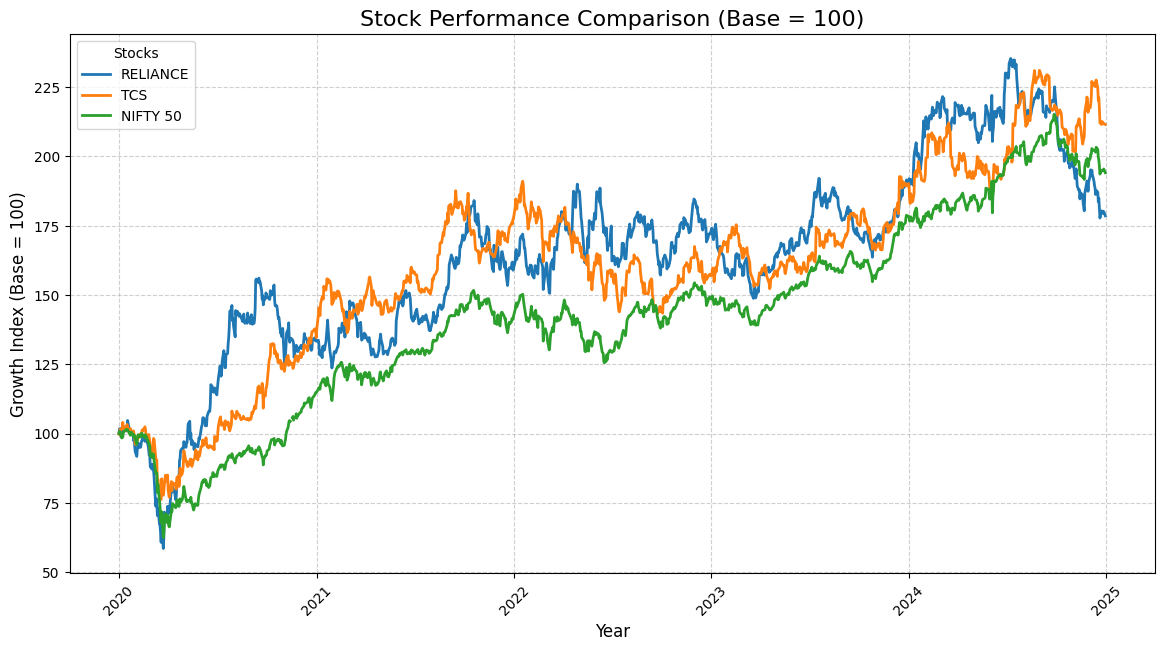

In [10]:
 #Normalize prices (Base = 100)
normalized = close / close.iloc[0] * 100
#Trend Analysis
labels = {
    'Close_RELIANCE.NS': 'RELIANCE',
    'Close_TCS.NS': 'TCS',
    'Close_^NSEI': 'NIFTY 50'
}

#Plot graph
plt.figure(figsize=(14,7))

for col in normalized.columns:
    plt.plot(
        normalized[col],
        linewidth=2,
        label=labels.get(col, col)  # fallback if name not found
    )

#Add title and labels
plt.title("Stock Performance Comparison (Base = 100)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Growth Index (Base = 100)", fontsize=12)

#Add grid
plt.grid(True, linestyle='--', alpha=0.6)

#Rotate x-axis labels
plt.xticks(rotation=45)

#Add legend
plt.legend(title="Stocks")

#Show plot
plt.show()

### 📌 Insights:
- RELIANCE shows moderate volatility  
- TCS appears more stable  
- NIFTY has lower risk compared to individual stocks  

## 📉 Returns & Volatility Analysis

Daily returns were calculated to analyze short-term price changes. Volatility was measured to assess risk.s.

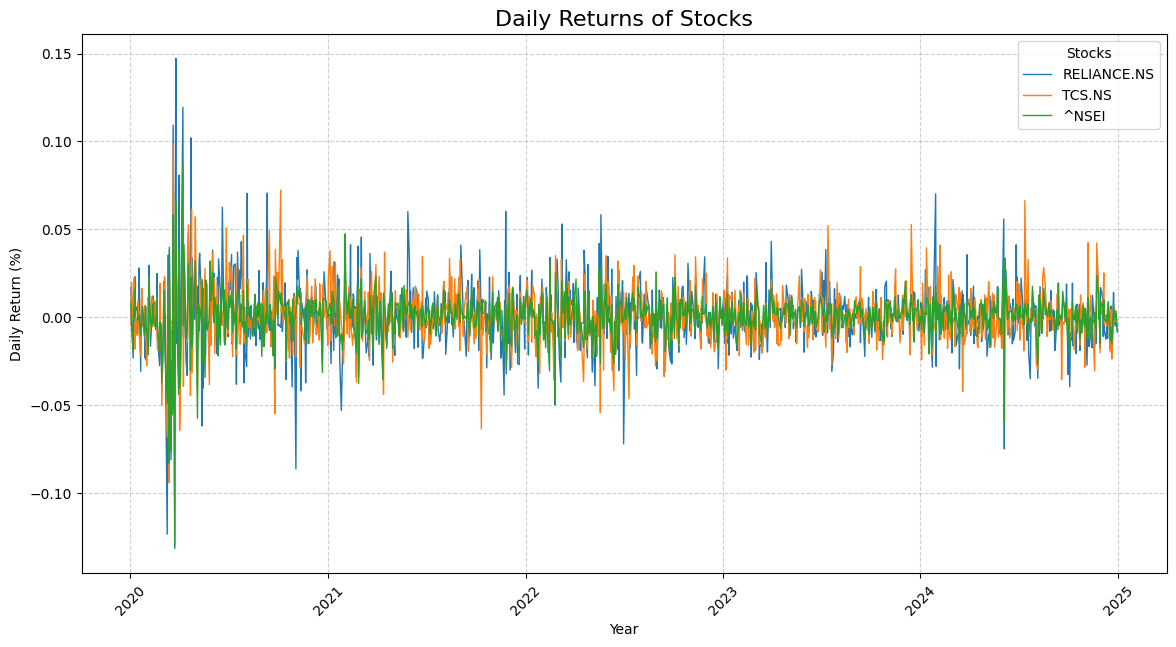

📊 Volatility (Risk Level):
Close_RELIANCE.NS    0.018750
Close_TCS.NS         0.015426
Close_^NSEI          0.012047
dtype: float64


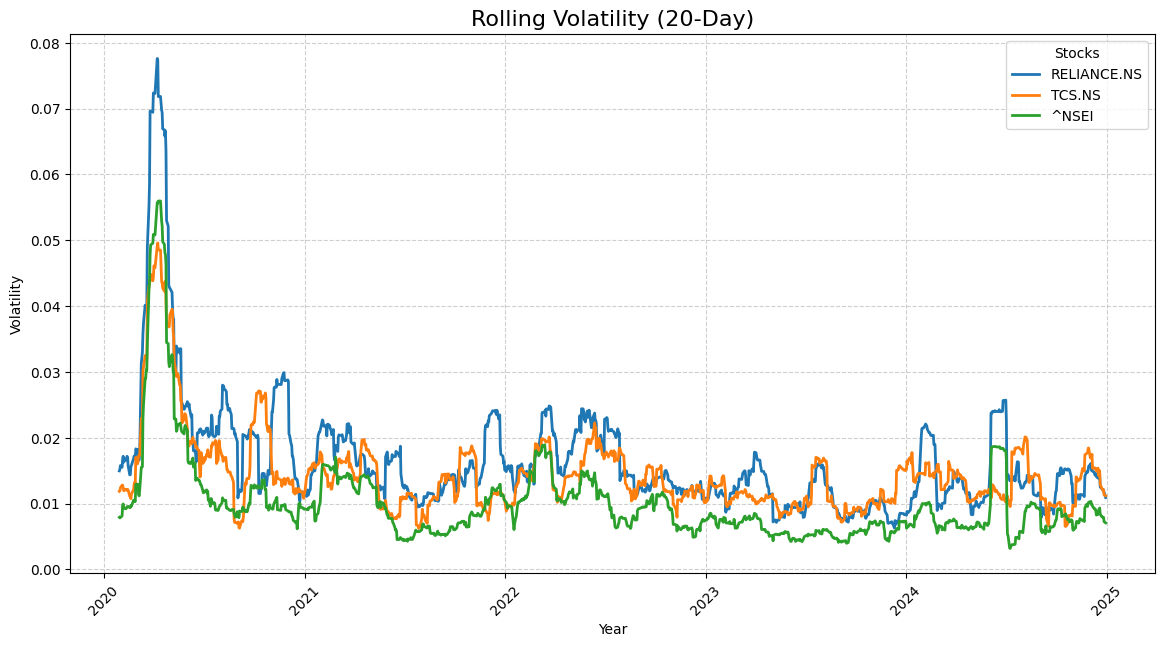

In [11]:
#Calculate Daily Returns
returns = close.pct_change(fill_method=None)

#Remove NaN values
returns.dropna(inplace=True)

#Plot Daily Returns
plt.figure(figsize=(14,7))

for col in returns.columns:
    plt.plot(returns[col], linewidth=1, label=col.replace('Close_', ''))

plt.title("Daily Returns of Stocks", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Daily Return (%)")
plt.legend(title="Stocks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.show()


#Volatility (Standard Deviation)
volatility = returns.std()

print("📊 Volatility (Risk Level):")
print(volatility)


#Rolling Volatility (20 days)
rolling_vol = returns.rolling(20).std()

plt.figure(figsize=(14,7))

for col in rolling_vol.columns:
    plt.plot(rolling_vol[col], linewidth=2, label=col.replace('Close_', ''))

plt.title("Rolling Volatility (20-Day)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.legend(title="Stocks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.show()



## 📦 Returns Distribution

This visualization shows how daily returns are distributed for each stock. It helps in understanding the risk, spread, and frequency of returns.


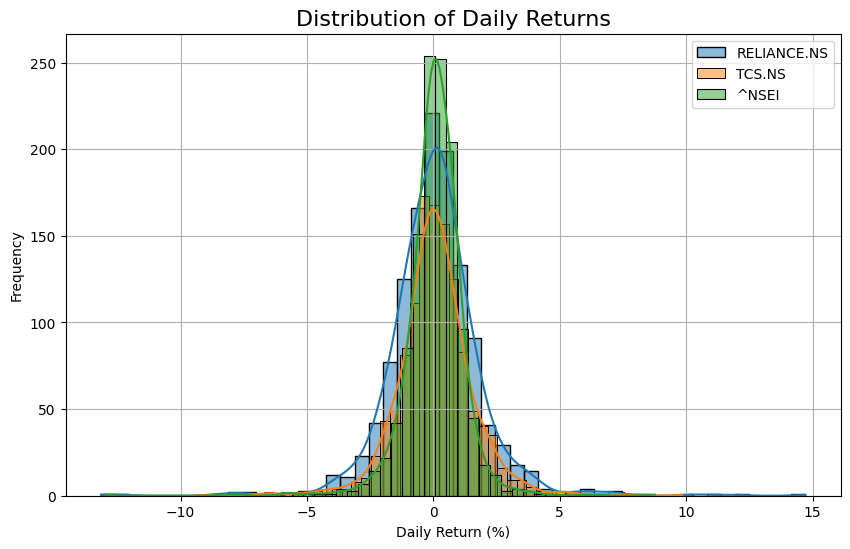

In [12]:
#Return Distribution
plt.figure(figsize=(10,6))

for col in returns.columns:
    sns.histplot(
        returns[col]*100,
        bins=50,
        kde=True,
        label=col.replace('Close_', ''),
        alpha=0.5
    )

plt.title("Distribution of Daily Returns", fontsize=16)
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

### 📌 Insights:
- Wider distribution indicates higher volatility  
- Narrow distribution indicates stability  
- Extreme values show potential risk  

## 📊 Cumulative Returns

Cumulative returns represent the total growth of an investment over time.


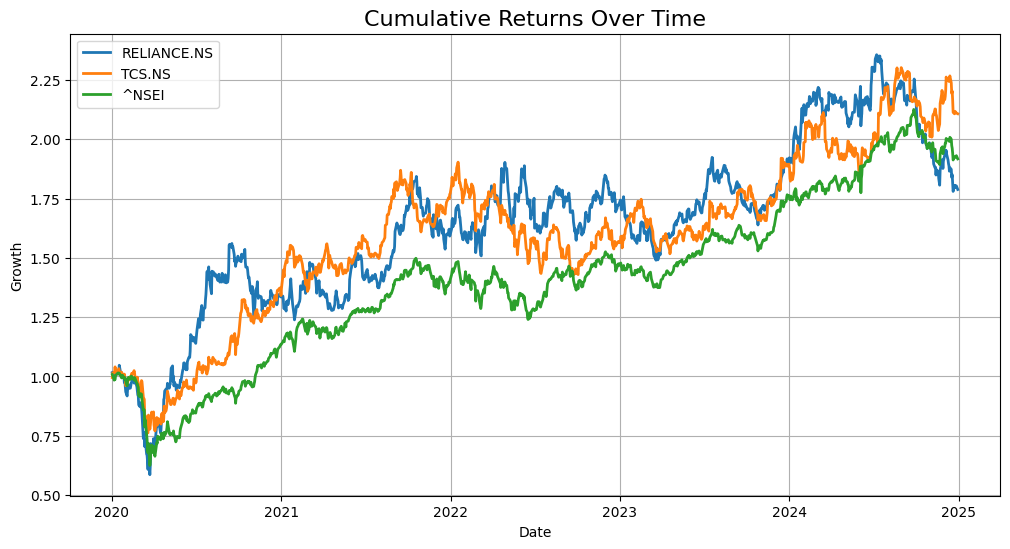

In [13]:
#Cumulative Returns
cumulative = (1 + returns).cumprod()

plt.figure(figsize=(12,6))

for col in cumulative.columns:
    plt.plot(
        cumulative[col],
        linewidth=2,
        label=col.replace('Close_', '')
    )

plt.title("Cumulative Returns Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.grid(True)

plt.show()

### 📌 Insights:
- Shows long-term performance of stocks  
- Helps compare overall growth  
- Useful for investment decisions  

## 📈 RSI (Relative Strength Index)

RSI is a momentum indicator used to identify overbought and oversold conditions in stock prices.

In [14]:
# RSI CALCULATION
# Select RELIANCE
rsi_data = close[['Close_RELIANCE.NS']].copy()

# Price change
delta = rsi_data['Close_RELIANCE.NS'].diff()

# Gains and losses
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Average gain/loss
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

# RSI formula
rs = avg_gain / avg_loss
rsi_data['RSI'] = 100 - (100 / (1 + rs))

rsi_data.dropna(inplace=True)

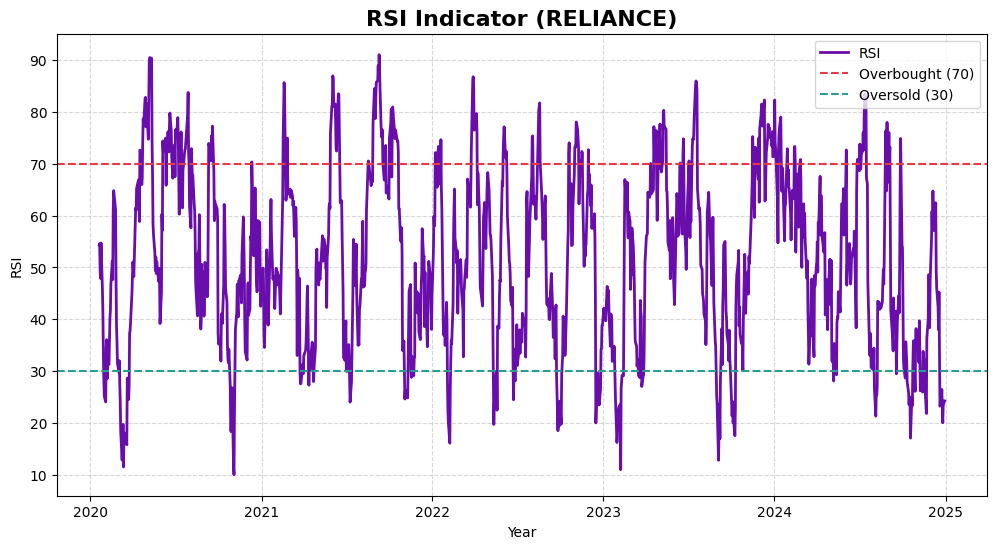

In [15]:
plt.figure(figsize=(12,6))

plt.plot(rsi_data['RSI'], color='#6a0dad', linewidth=2, label='RSI')

# Overbought / Oversold
plt.axhline(70, color='#e63946', linestyle='--', linewidth=1.5, label='Overbought (70)')
plt.axhline(30, color='#2a9d8f', linestyle='--', linewidth=1.5, label='Oversold (30)')

plt.title("RSI Indicator (RELIANCE)", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("RSI")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 📌 Insights:

- RSI above 70 indicates overbought condition  
- RSI below 30 indicates oversold condition  
- Helps identify potential buy/sell opportunities  

### 📌 Insights:
- RELIANCE shows moderate volatility  
- TCS appears more stable  
- NIFTY has lower risk compared to individual stocks  

## 🔗 Correlation Analysis

Correlation analysis was performed to understand relationships between stocks.

In [16]:
#Calculate correlation matrix
corr = returns.corr()

print("📊 Correlation Matrix:")
print(corr)


📊 Correlation Matrix:
                   Close_RELIANCE.NS  Close_TCS.NS  Close_^NSEI
Close_RELIANCE.NS           1.000000      0.386851     0.715394
Close_TCS.NS                0.386851      1.000000     0.586859
Close_^NSEI                 0.715394      0.586859     1.000000


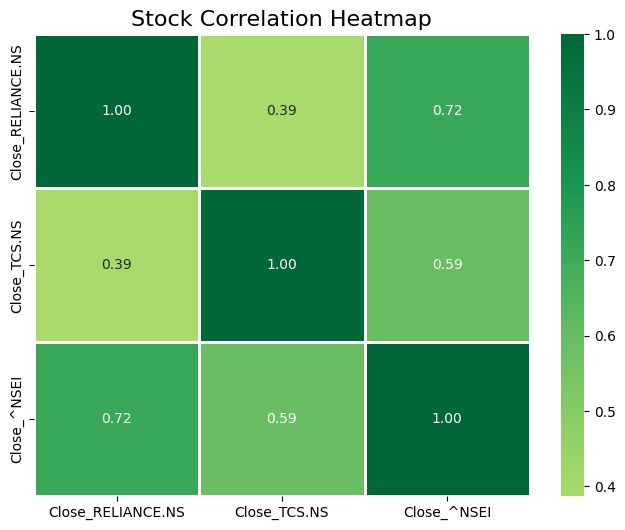

In [17]:
#Heatmap Visualization
plt.figure(figsize=(8,6))
plt.tight_layout()
sns.heatmap(
    corr,
    annot=True,          # show values
    cmap='RdYlGn',       # better color scheme
    center=0,            # center at 0
    linewidths=1,
    fmt=".2f"
)
plt.title("Stock Correlation Heatmap", fontsize=16)
plt.show()

### 📌 Insights:
- RELIANCE and NIFTY are highly correlated  
- TCS shows moderate independence  
- Useful for diversification strategy  

## 📊 Scatter Plot Analysis

This plot shows the relationship between returns of two stocks.


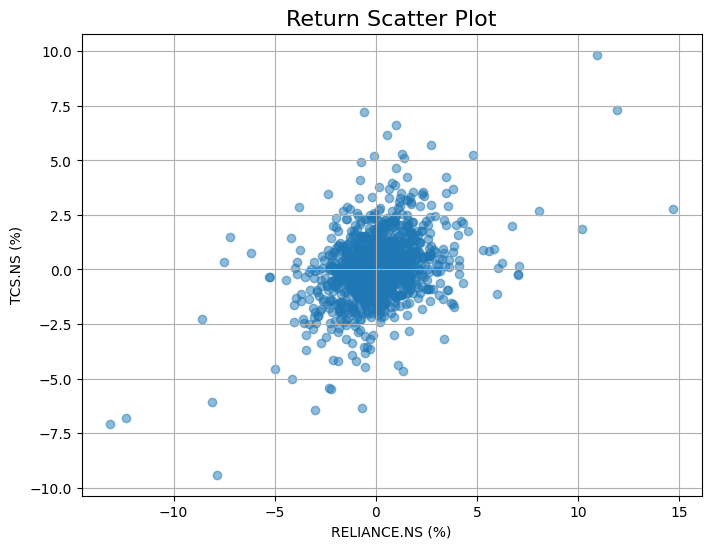

In [18]:
plt.figure(figsize=(8,6))

x = returns.iloc[:,0] * 100
y = returns.iloc[:,1] * 100

plt.scatter(x, y, alpha=0.5)

plt.title("Return Scatter Plot", fontsize=16)
plt.xlabel(returns.columns[0].replace('Close_', '') + " (%)")
plt.ylabel(returns.columns[1].replace('Close_', '') + " (%)")

plt.grid(True)
plt.show()

### 📌 Insights:
- Positive slope indicates positive correlation  
- Negative slope indicates inverse relationship  
- Helps in diversification analysis  

## 📚Stock Price Prediction

A Linear Regression model was used to predict next-day stock prices based on historical data.

In [19]:
#Select RELIANCE data
data = close[['Close_RELIANCE.NS']].copy()

#Create target variable (next day price)
data['Prediction'] = data['Close_RELIANCE.NS'].shift(-1)

#Remove last row (NaN)
data.dropna(inplace=True)

#Features (X) and Target (y)
X = data[['Close_RELIANCE.NS']]
y = data['Prediction']

#Train-Test Split (NO SHUFFLE for time series)
split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#Train Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predict
predictions = model.predict(X_test)

#Evaluate
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)
# Add lag feature
data['Lag1'] = data['Close_RELIANCE.NS'].shift(1)
data.dropna(inplace=True)

X = data[['Close_RELIANCE.NS', 'Lag1']]
y = data['Prediction']

Mean Squared Error: 413.13870132324286


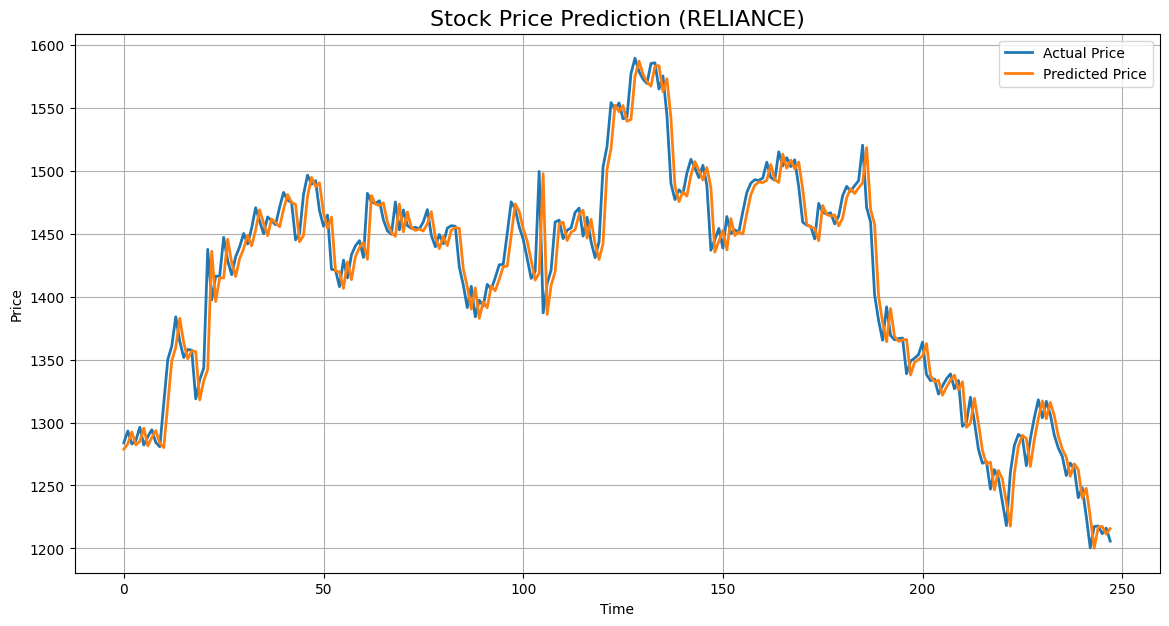

In [20]:
#Plot Results
plt.figure(figsize=(14,7))

plt.plot(y_test.values, label='Actual Price', linewidth=2)
plt.plot(predictions, label='Predicted Price', linewidth=2)

plt.title("Stock Price Prediction (RELIANCE)", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

📌 Prediction Model

A Linear Regression model was used to predict the next day's stock price based on current price. The dataset was split into training and testing sets without shuffling to preserve time-series order.

📌 Model Evaluation

The model performance was evaluated using Mean Squared Error (MSE). The predicted values closely follow the actual trend, indicating reasonable prediction capability.

### 📌 Insights:
- Model captures general trend of stock prices  
- Prediction closely follows actual values  
- Suitable for basic forecasting  

## ✅ Conclusion

- Successfully analyzed stock trends and volatility  
- Identified relationships between stocks  
- Built a predictive model for future prices  
- Demonstrated end-to-end data analytics workflow  

This project showcases practical application of data analysis and machine learning in financial markets.